### Project Overview

The goal of this project is to perform an end-to-end data analysis and machine learning pipeline on the Titanic dataset, identifying the key factors that influenced passenger survival.

This includes:

* Data cleaning and handling missing values
* Exploratory Data Analysis (EDA) to understand distributions and relationships
* Feature engineering to extract meaningful information from raw data
* Data preparation and transformation for modeling
* Training and evaluation of multiple machine learning models
* Model comparison using performance metrics (accuracy, precision, recall, F1-score)
* Model interpretation through feature importance analysis


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Data Comprehension

In [13]:
print("Shape of dataset:", train.shape)
train.head()

Shape of dataset: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [14]:
print("\nData Types and Non-Null Counts:\n")
train.info()


Data Types and Non-Null Counts:

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [15]:
print("\nStatistical Summary:\n")
train.describe()


Statistical Summary:



,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [16]:
print("\nMissing Values:\n")
train.isnull().sum().sort_values(ascending=False)


Missing Values:



Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

In [17]:
print("\nDuplicates:\n")
train.duplicated().sum()


Duplicates:



np.int64(0)

#### Observations

- Age has missing values and will require imputation
- Cabin has a large number of missing values and may be dropped
- Embarked has few missing values and can be easily filled
- Dataset contains a mix of numerical and categorical features

---

#### Exploratory Data Analysis (EDA)

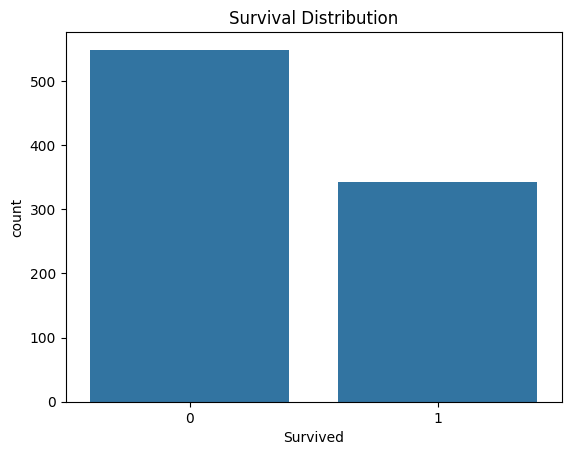

In [18]:
sns.countplot(x="Survived", data=train)
plt.title("Survival Distribution")
plt.show()

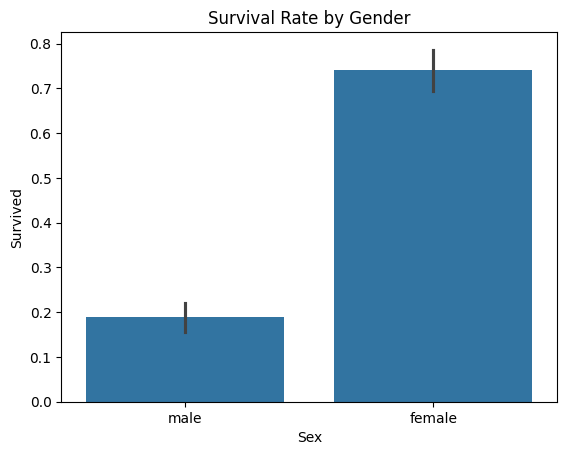

In [19]:
sns.barplot(x="Sex", y="Survived", data=train)
plt.title("Survival Rate by Gender")
plt.show()

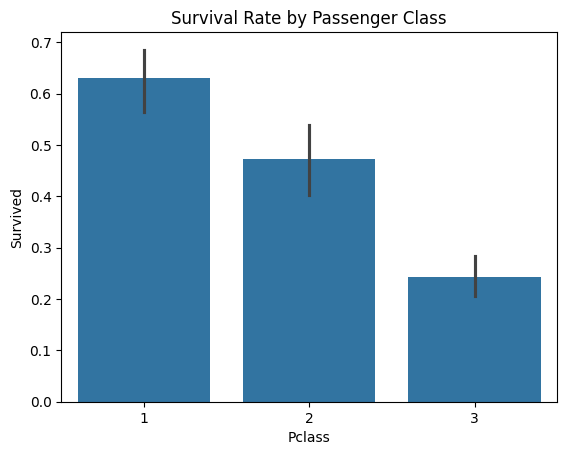

In [20]:
sns.barplot(x="Pclass", y="Survived", data=train)
plt.title("Survival Rate by Passenger Class")
plt.show()

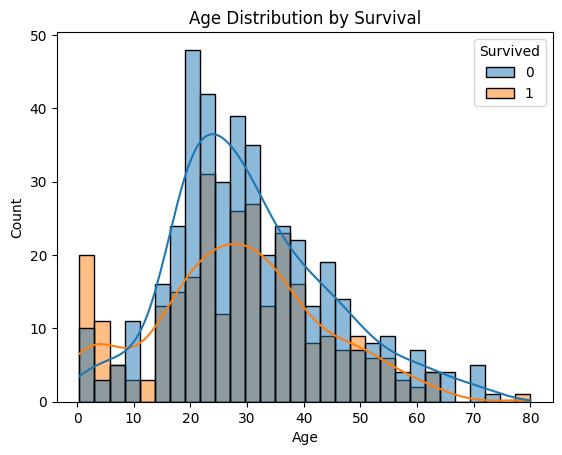

In [21]:
sns.histplot(data=train, x="Age", hue="Survived", bins=30, kde=True)
plt.title("Age Distribution by Survival")
plt.show()

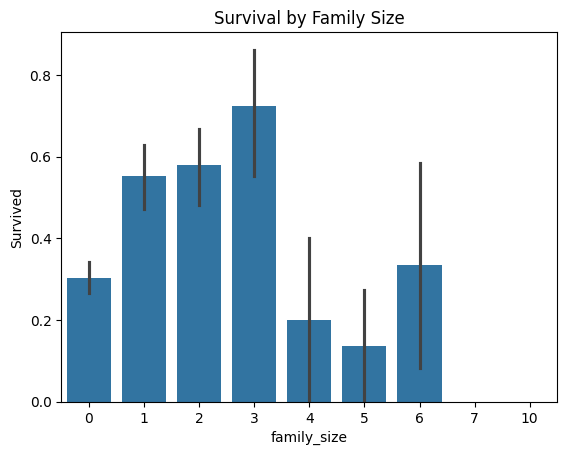

In [22]:
train["family_size"] = train["SibSp"] + train["Parch"]

sns.barplot(x="family_size", y="Survived", data=train)
plt.title("Survival by Family Size")
plt.show()

In [23]:
def categorize_family(size):
    if size == 0:
        return "alone"
    elif size <= 3:
        return "small"
    else:
        return "large"

In [24]:
train["family_group"] = train["family_size"].apply(categorize_family)

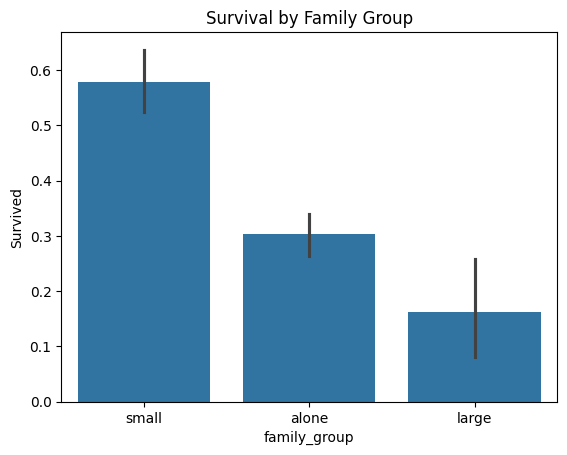

In [25]:
train["family_size"] = train["SibSp"] + train["Parch"]

sns.barplot(x="family_group", y="Survived", data=train)
plt.title("Survival by Family Group")
plt.show()

##### **Insight**

Passengers traveling alone had lower survival rates.
Small families (1–3 members) had the highest survival probability.
Large families showed lower survival rates, possibly due to evacuation difficulty.

This suggests that family structure plays an important role in survival and should be considered in feature engineering.

In [26]:
# Extract title (e.g., Mr, Mrs, Miss) from the Name column using regex
# Explanation:
# - The pattern " ([A-Za-z]+)\." searches for:
#     * a space before the title
#     * one or more letters ([A-Za-z]+)
#     * followed by a dot (\.)
# - Parentheses () define the capture group, meaning only the title (e.g., "Mr") is extracted
# - expand=False ensures the result is returned as a pandas Series (single column)
# This creates a new feature that captures gender, age group, and social status information

train["title"] = train["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)

train["title"].value_counts()

title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [27]:
def simplify_title(title):
    if title in ["Mr"]:
        return "Mr"
    elif title in ["Miss", "Mlle"]:
        return "Miss"
    elif title in ["Mrs", "Mme"]:
        return "Mrs"
    elif title in ["Master"]:
        return "Master"
    else:
        return "Rare"

train["title_grouped"] = train["title"].apply(simplify_title)

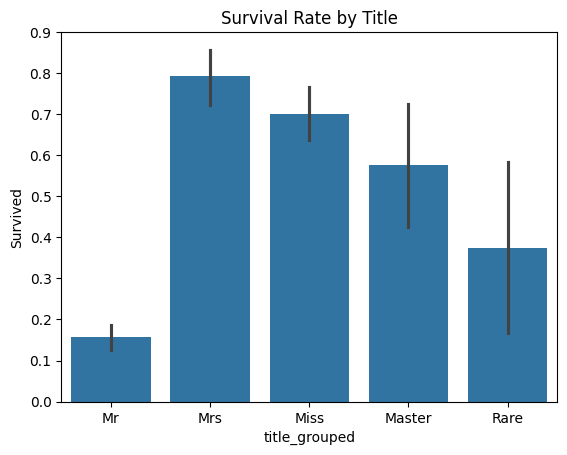

In [28]:
sns.barplot(x="title_grouped", y="Survived", data=train)
plt.title("Survival Rate by Title")
plt.show()

##### **Insight**

The extracted title feature reveals strong patterns:

- "Mr" (adult males) have the lowest survival rate
- "Miss" and "Mrs" show significantly higher survival rates
- "Master" (young boys) also have higher survival probability

This feature captures both gender and social/age-related information, making it highly valuable for modeling.

---

#### Outliers

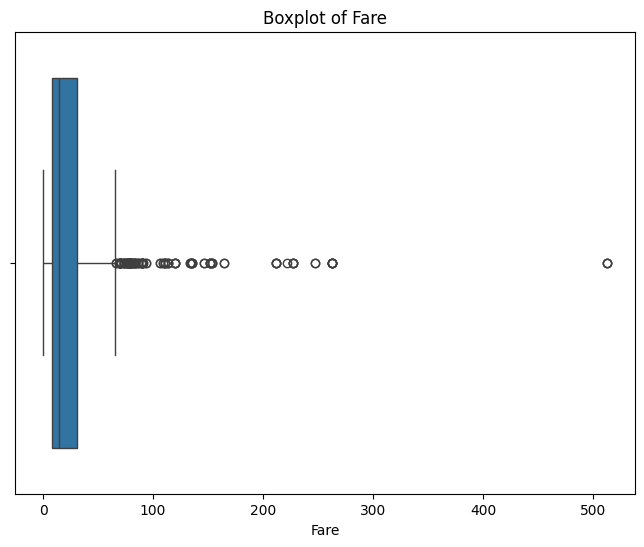

In [29]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=train["Fare"])
plt.title("Boxplot of Fare")
plt.show()

# Although outliers are present in Fare, they likely represent real high-paying passengers.
# Instead of removing them, we apply a log transformation to reduce skewness.

In [30]:
Q1 = train["Fare"].quantile(0.25)
Q3 = train["Fare"].quantile(0.75)
IQR = Q3 - Q1
outliers = train[(train["Fare"] < Q1 - 1.5 * IQR) | (train["Fare"] > Q3 + 1.5 * IQR)]
print(f"Number of outliers in Fare: {outliers.shape[0]}")

Number of outliers in Fare: 116


Prepare data for modeling and handle missing values

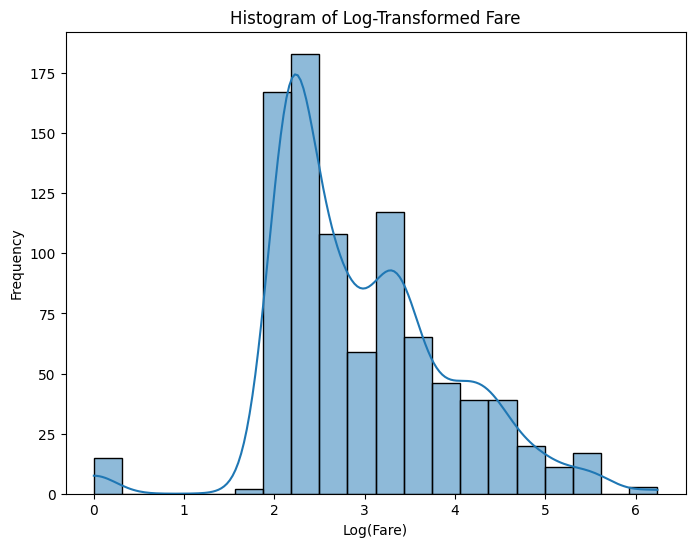

In [ ]:
train_cleaned = train.copy()
train_cleaned["Age"] = train_cleaned["Age"].fillna(train_cleaned["Age"].median()) # Fill missing Age values with median age
train_cleaned["Embarked"] = train_cleaned["Embarked"].fillna("Unknown") # Fill missing embarked values with "Unknown"
train_cleaned.dropna(subset=["Fare"], inplace=True) # Drop rows with missing Fare values

# Apply log transformation to reduce skewness in Fare distribution 
train_cleaned["fare_log"] = np.log1p(train_cleaned["Fare"]) # log(1 + fare) to handle skewness and reduce the impact of outliers

# Visualize new distribution
plt.figure(figsize=(8, 6))
sns.histplot(train_cleaned["fare_log"], bins=20, kde=True)
plt.title("Histogram of Log-Transformed Fare")
plt.xlabel("Log(Fare)")
plt.ylabel("Frequency")
plt.show()

*Outlier Analysis - Fare*

- The Fare variable shows significant right skewness with several high-value outliers
- These outliers likely represent high-class passengers and are not data errors
- Instead of removing them, a log transformation was applied to reduce skewness
- This transformation helps stabilize variance and improves model performance
---

### Data Preparation & Modeling

Select relevant features based on EDA and feature engineering

In [ ]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "fare_log",
    "Embarked",
    "family_group",
    "title_grouped"
]

target = "Survived"

df_model = train_cleaned[features + [target]].copy()
df_model.head()

,Pclass,Sex,Age,fare_log,Embarked,family_group,title_grouped,Survived
0,3,male,22.0,2.110213,S,small,Mr,0
1,1,female,38.0,4.280593,C,small,Mrs,1
2,3,female,26.0,2.188856,S,alone,Miss,1
3,1,female,35.0,3.990834,S,small,Mrs,1
4,3,male,35.0,2.202765,S,alone,Mr,0


Convert 'Sex' to numerical values (binary encoding)
male -> 0, female -> 1

In [ ]:
df_model["Sex"] = df_model["Sex"].map({"male": 0, "female": 1})

Apply one-hot encoding to categorical variables
This converts categories into binary columns (0/1)

Example: For 'Embarked' with categories 'C', 'Q', 'S', and 'Unknown', we create new columns:
- Embarked_C: 1 if Embarked is 'C', else 0
- Embarked_Q: 1 if Embarked is 'Q', else 0
- Embarked_S: 1 if Embarked is 'S', else 0
- Embarked_Unknown: 1 if Embarked is 'Unknown', else 0

In [34]:
df_model = pd.get_dummies(
    df_model,
    columns=["Embarked", "family_group", "title_grouped"],
    drop_first=True  # Avoid multicollinearity
)

In [35]:
df_model.columns

Index(['Pclass', 'Sex', 'Age', 'fare_log', 'Survived', 'Embarked_Q',
       'Embarked_S', 'Embarked_Unknown', 'family_group_large',
       'family_group_small', 'title_grouped_Miss', 'title_grouped_Mr',
       'title_grouped_Mrs', 'title_grouped_Rare'],
      dtype='str')

In [36]:
df_model.isnull().sum()

Pclass                0
Sex                   0
Age                   0
fare_log              0
Survived              0
Embarked_Q            0
Embarked_S            0
Embarked_Unknown      0
family_group_large    0
family_group_small    0
title_grouped_Miss    0
title_grouped_Mr      0
title_grouped_Mrs     0
title_grouped_Rare    0
dtype: int64

Separate features (X) and target (y)

In [37]:
X = df_model.drop(columns=["Survived"])
y = df_model["Survived"]

Split dataset into training and testing sets
(80% training / 20% testing)

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [39]:
print(X_train.shape)
print(X_test.shape)

(712, 13)
(179, 13)


In [40]:
y.value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

Initialize Scaler

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

Scale numerical features
Fit only on training data to avoid data leakage

In [43]:
X_train[["Age", "fare_log"]] = scaler.fit_transform(X_train[["Age", "fare_log"]])

Apply transformation to test data

In [44]:
X_test[["Age", "fare_log"]] = scaler.transform(X_test[["Age", "fare_log"]])

Initialize and train model(s)

In [48]:
# ==============================
# Logistic Regression Model
# ==============================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Initialize model
lr = LogisticRegression(max_iter=1000)

# Train model
lr.fit(X_train, y_train)

# Predictions
y_pred_lr = lr.predict(X_test)

# Evaluation
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.8156424581005587


In [49]:
# ==============================
# Random Forest Model
# ==============================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Initialize model
rf = RandomForestClassifier(random_state=42)

# Train model
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Evaluation
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8324022346368715


In [50]:
# ==============================
# Gradient Boosting Model
# ==============================

from sklearn.ensemble import GradientBoostingClassifier

# Initialize model
gb = GradientBoostingClassifier(random_state=42)

# Train model
gb.fit(X_train, y_train)

# Predictions
y_pred_gb = gb.predict(X_test)

# Evaluation
gb_accuracy = accuracy_score(y_test, y_pred_gb)

print("Gradient Boosting Accuracy:", gb_accuracy)

Gradient Boosting Accuracy: 0.8100558659217877


In [51]:
# ==============================
# Model Comparison
# ==============================

print("Logistic Regression Accuracy:", lr_accuracy)
print("Random Forest Accuracy:", rf_accuracy)
print("Gradient Boosting Accuracy:", gb_accuracy)

Logistic Regression Accuracy: 0.8156424581005587
Random Forest Accuracy: 0.8324022346368715
Gradient Boosting Accuracy: 0.8100558659217877


**Model Comparison**

Three different models were evaluated:

- Logistic Regression provided a strong baseline with ~81% accuracy
- Random Forest achieved the best performance (~83%), likely due to its ability to capture non-linear relationships
- Gradient Boosting performed similarly but did not outperform Random Forest in this case

The relatively small difference between models suggests that feature engineering played a key role in model performance.

Further improvements could be achieved through hyperparameter tuning and additional feature engineering.

Classification Report

In [52]:
from sklearn.metrics import classification_report

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.85      0.84       105
           1       0.78      0.77      0.78        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



In [53]:
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.86       105
           1       0.79      0.81      0.80        74

    accuracy                           0.83       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.83      0.83      0.83       179



In [54]:
print("Gradient Boosting Classification Report:")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.72      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



**Classification Report**

The classification report provides a detailed evaluation of model performance:

- Precision measures how accurate the positive predictions are
- Recall measures how well the model identifies actual positive cases
- F1-score balances precision and recall

This allows for a deeper understanding of model performance beyond accuracy, especially in cases where class distribution is not perfectly balanced.

- Logistic Regression showed balanced performance with good precision and recall
- Random Forest achieved the best overall performance, with the highest recall (0.81) and F1-score for the positive class (survivors)
- Gradient Boosting had lower recall for the positive class, indicating it missed more actual survivors

This analysis shows that Random Forest not only achieved higher accuracy, but also performed better in identifying passengers who survived, making it the most effective model among those tested.

---

### Feature Importance (Random Forest)

In [55]:
import pandas as pd

# Get feature importance values
importances = rf.feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
})

# Sort values
feature_importance = feature_importance.sort_values(by="importance", ascending=False)

feature_importance.head(10)

,feature,importance
3,fare_log,0.262101
2,Age,0.240755
10,title_grouped_Mr,0.135849
1,Sex,0.116506
0,Pclass,0.077819
11,title_grouped_Mrs,0.036895
7,family_group_large,0.034150
8,family_group_small,0.029113
9,title_grouped_Miss,0.028248
5,Embarked_S,0.020363


*Feature Importance Analysis*

The Random Forest model provides insights into which features were most important for predicting survival.

- Features such as Sex, Fare, and Pclass are expected to have high importance, as they are strongly related to survival probability
- Engineered features like title_grouped and family_group also contribute to model performance
- This analysis helps us understand how the model makes decisions and which variables have the greatest predictive power

Overall, feature importance confirms that both original and engineered features play a key role in predicting survival.

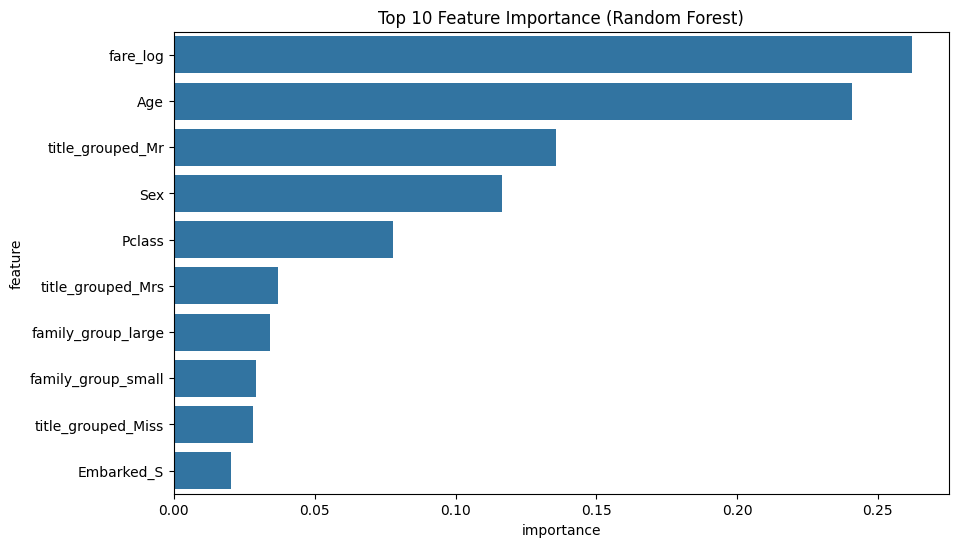

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot top features
plt.figure(figsize=(10,6))
sns.barplot(
    x="importance",
    y="feature",
    data=feature_importance.head(10)
)

plt.title("Top 10 Feature Importance (Random Forest)")
plt.show()

*Feature Importance Analysis*

The feature importance results provide valuable insights into the factors influencing survival.

- Fare (log-transformed) and Age are the most important features, indicating that socioeconomic status and age played a major role
- The feature "title_grouped_Mr" has high importance, suggesting that adult males had significantly lower survival rates
- Interestingly, the "Sex" feature is less important than expected, likely because the "title" feature captures more detailed information about gender and social status
- Pclass also contributes, but its impact is partially captured by the Fare feature

These results highlight the importance of feature engineering, as engineered features such as title_grouped and fare_log provide more predictive power than some original variables.

**What mattered most in survival?**

Socioeconomic status, age, and gender-related roles were the key drivers, and this was captured through features like fare, age, and extracted titles.